# Music Recommendation System
**MAL Exam Project**

This notebook builds a content-based music recommender using the Spotify 160k songs dataset.

**Pipeline:**
1. Load dataset from Kaggle
2. Clean the data
3. Explore the data (EDA)
4. Train a K-Means clustering model
5. Evaluate the model
6. Build a recommendation function
7. Save the model for deployment

**Problem:** Given a song the user likes, recommend 10 similar songs based on audio features (energy, danceability, valence, etc.).

## 1. Setup — Install and Import Libraries

In [1]:
# Install kagglehub if not already installed (Colab usually has it)
!pip install kagglehub --quiet

In [2]:
import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from sklearn.metrics.pairwise import cosine_similarity

# Make plots look nicer
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

## 2. Load Data
We use `kagglehub` to download the dataset directly. No manual file uploads needed.

In [3]:
# Download the dataset
path = kagglehub.dataset_download("fcpercival/160k-spotify-songs-sorted")
print("Path to dataset files:", path)

100%|██████████| 13.5M/13.5M [00:00<00:00, 106MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/fcpercival/160k-spotify-songs-sorted/versions/1


In [4]:
# Load the CSV into a pandas DataFrame
import os
csv_file = os.path.join(path, "data.csv")
df = pd.read_csv(csv_file)

print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (169907, 19)


,id,name,artists,duration_ms,release_date,year,acousticness,danceability,energy,instrumentalness,liveness,loudness,speechiness,tempo,valence,mode,key,popularity,explicit
0,0gNNToCW3qjabgTyBSjt3H,!Que Vida! - Mono Version,['Love'],220560,11/1/66,1966,0.5250,0.600,0.540,0.00305,0.100,-11.803,0.0328,125.898,0.547,1,9,26,0
1,0tMgFpOrXZR6irEOLNWwJL,"""40""",['U2'],157840,2/28/83,1983,0.2280,0.368,0.480,0.70700,0.159,-11.605,0.0306,150.166,0.338,1,8,21,0
2,2ZywW3VyVx6rrlrX75n3JB,"""40"" - Live",['U2'],226200,8/20/83,1983,0.0998,0.272,0.684,0.01450,0.946,-9.728,0.0505,143.079,0.279,1,8,41,0
3,6DdWA7D1o5TU2kXWyCLcch,"""40"" - Remastered 2008",['U2'],157667,2/28/83,1983,0.1850,0.371,0.545,0.58200,0.183,-9.315,0.0307,150.316,0.310,1,8,37,0
4,3vMmwsAiLDCfyc1jl76lQE,"""40"" - Remastered 2008",['U2'],157667,2/28/83,1983,0.1850,0.371,0.545,0.58200,0.183,-9.315,0.0307,150.316,0.310,1,8,35,0


## 3. Inspect the Data
Look at column types, missing values, and basic statistics.

In [5]:
# Column data types and non-null counts
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 169907 entries, 0 to 169906
Data columns (total 19 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   id                169907 non-null  object 
 1   name              169907 non-null  object 
 2   artists           169907 non-null  object 
 3   duration_ms       169907 non-null  int64  
 4   release_date      169907 non-null  object 
 5   year              169907 non-null  int64  
 6   acousticness      169907 non-null  float64
 7   danceability      169907 non-null  float64
 8   energy            169907 non-null  float64
 9   instrumentalness  169907 non-null  float64
 10  liveness          169907 non-null  float64
 11  loudness          169907 non-null  float64
 12  speechiness       169907 non-null  float64
 13  tempo             169907 non-null  float64
 14  valence           169907 non-null  float64
 15  mode              169907 non-null  int64  
 16  key               16

In [6]:
# Basic statistics for numerical columns
df.describe()

,duration_ms,year,acousticness,danceability,energy,instrumentalness,liveness,loudness,speechiness,tempo,valence,mode,key,popularity,explicit
count,1.699070e+05,169907.000000,169907.000000,169907.000000,169907.000000,169907.000000,169907.000000,169907.000000,169907.000000,169907.000000,169907.000000,169907.000000,169907.000000,169907.000000,169907.000000
mean,2.314071e+05,1977.223234,0.493217,0.538147,0.488591,0.161939,0.206692,-11.370311,0.094058,116.947850,0.532091,0.708552,5.200498,31.556681,0.084864
std,1.213223e+05,25.593318,0.376628,0.175345,0.267391,0.309330,0.176797,5.666795,0.149938,30.727079,0.262407,0.454431,3.515272,21.582730,0.278680
min,5.108000e+03,1921.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-60.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1.710400e+05,1957.000000,0.094500,0.417000,0.263000,0.000000,0.098400,-14.470000,0.034900,93.516000,0.322000,0.000000,2.000000,12.000000,0.000000
50%,2.086000e+05,1978.000000,0.492000,0.548000,0.481000,0.000204,0.135000,-10.474000,0.045000,114.777000,0.544000,1.000000,5.000000,33.000000,0.000000
75%,2.629665e+05,1999.000000,0.888000,0.667000,0.710000,0.086800,0.263000,-7.118000,0.075400,135.712000,0.749000,1.000000,8.000000,48.000000,0.000000
max,5.403500e+06,2020.000000,0.996000,0.988000,1.000000,1.000000,1.000000,3.855000,0.969000,244.091000,1.000000,1.000000,11.000000,100.000000,1.000000


In [7]:
# Check for missing values
print("Missing values per column:")
print(df.isnull().sum())

Missing values per column:
id                  0
name                0
artists             0
duration_ms         0
release_date        0
year                0
acousticness        0
danceability        0
energy              0
instrumentalness    0
liveness            0
loudness            0
speechiness         0
tempo               0
valence             0
mode                0
key                 0
popularity          0
explicit            0
dtype: int64


## 4. Clean the Data
Steps:
1. Drop duplicate songs (same name + same artist)
2. Remove "zero tempo" non-songs (these are sleep noises, not music)
3. Keep only relevant audio features for modelling

In [8]:
# Before cleaning
print(f"Rows before cleaning: {len(df)}")

# 1. Drop duplicates based on song name and artist
df = df.drop_duplicates(subset=['name', 'artists'])

# 2. Remove non-songs (sleep sounds with zero tempo / zero danceability)
df = df[(df['tempo'] > 0) & (df['danceability'] > 0)]

# 3. Drop any remaining missing values
df = df.dropna()

# Reset index after cleaning
df = df.reset_index(drop=True)

print(f"Rows after cleaning: {len(df)}")

Rows before cleaning: 169907
Rows after cleaning: 156467


In [9]:
# Define which audio features we'll use for modelling
audio_features = [
    'acousticness', 'danceability', 'energy', 'instrumentalness',
    'liveness', 'loudness', 'speechiness', 'tempo', 'valence'
]

# Preview the features
df[audio_features].head()

,acousticness,danceability,energy,instrumentalness,liveness,loudness,speechiness,tempo,valence
0,0.525000,0.600,0.540,0.00305,0.100,-11.803,0.0328,125.898,0.547
1,0.228000,0.368,0.480,0.70700,0.159,-11.605,0.0306,150.166,0.338
2,0.099800,0.272,0.684,0.01450,0.946,-9.728,0.0505,143.079,0.279
3,0.185000,0.371,0.545,0.58200,0.183,-9.315,0.0307,150.316,0.310
4,0.000696,0.315,0.970,0.00000,0.277,-4.709,0.1020,178.068,0.423


## 5. Exploratory Data Analysis (EDA)
Visualise the data to understand it before training.

**📸 Screenshot tip:** The plots in this section are great candidates for your hand-in.

### 5.1 Distribution of audio features
How are the audio features spread across all songs?

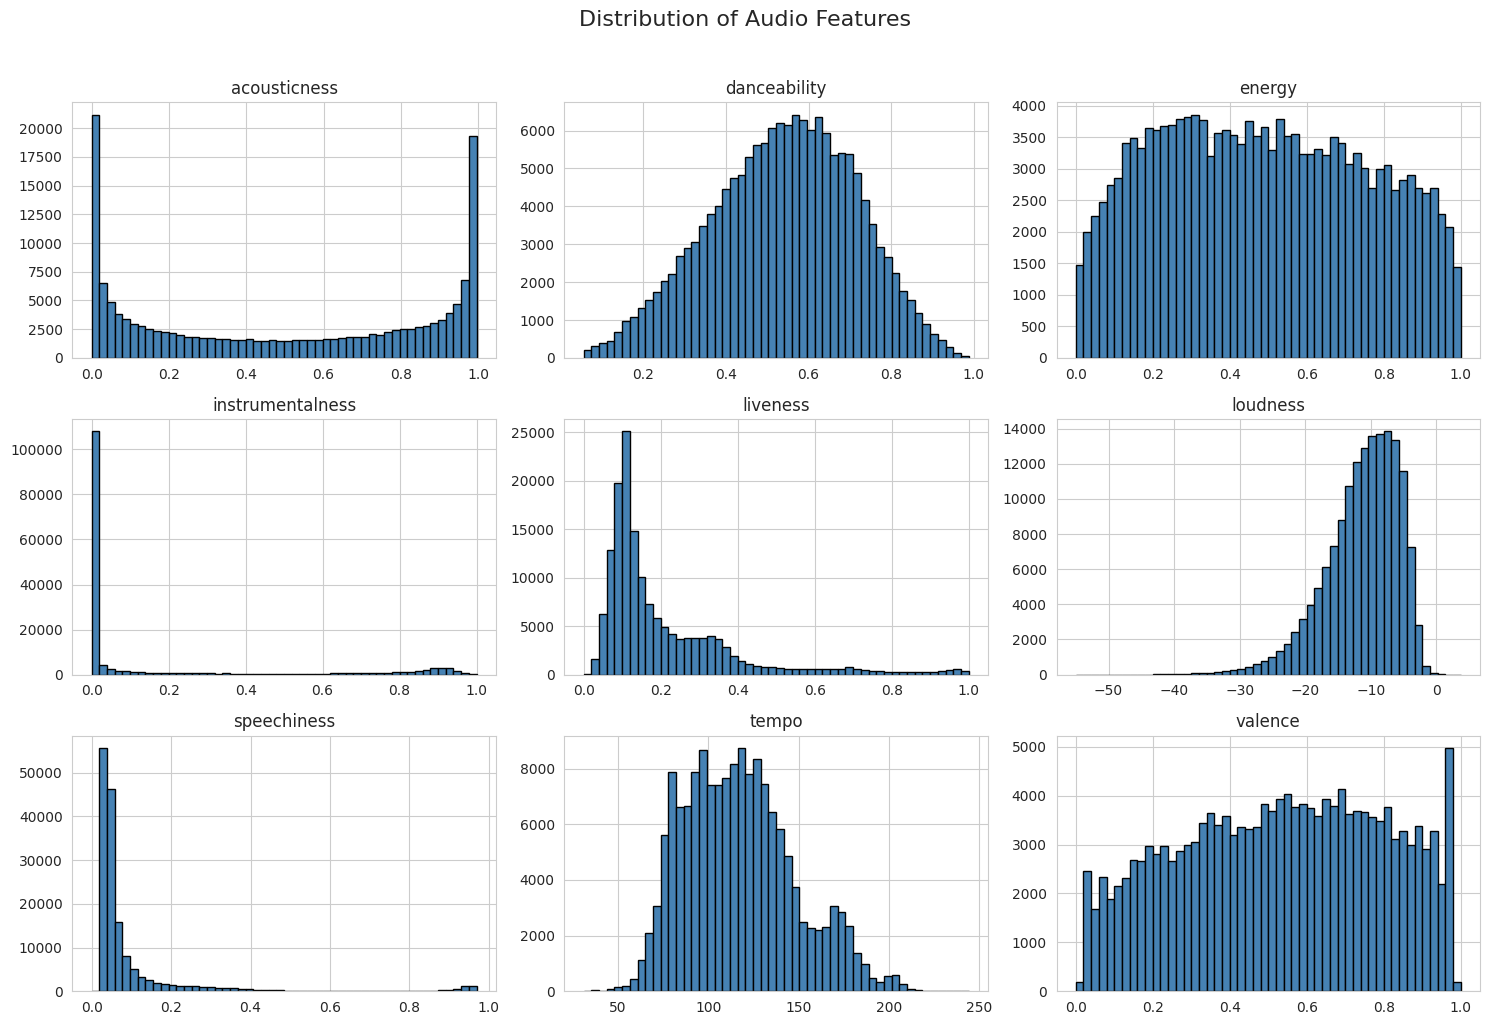

In [10]:
# Plot distribution histograms for each audio feature
fig, axes = plt.subplots(3, 3, figsize=(15, 10))
axes = axes.flatten()

for i, feature in enumerate(audio_features):
    axes[i].hist(df[feature], bins=50, color='steelblue', edgecolor='black')
    axes[i].set_title(feature, fontsize=12)
    axes[i].set_xlabel("")

plt.suptitle("Distribution of Audio Features", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

### 5.2 Correlation heatmap
Which features are related to each other?

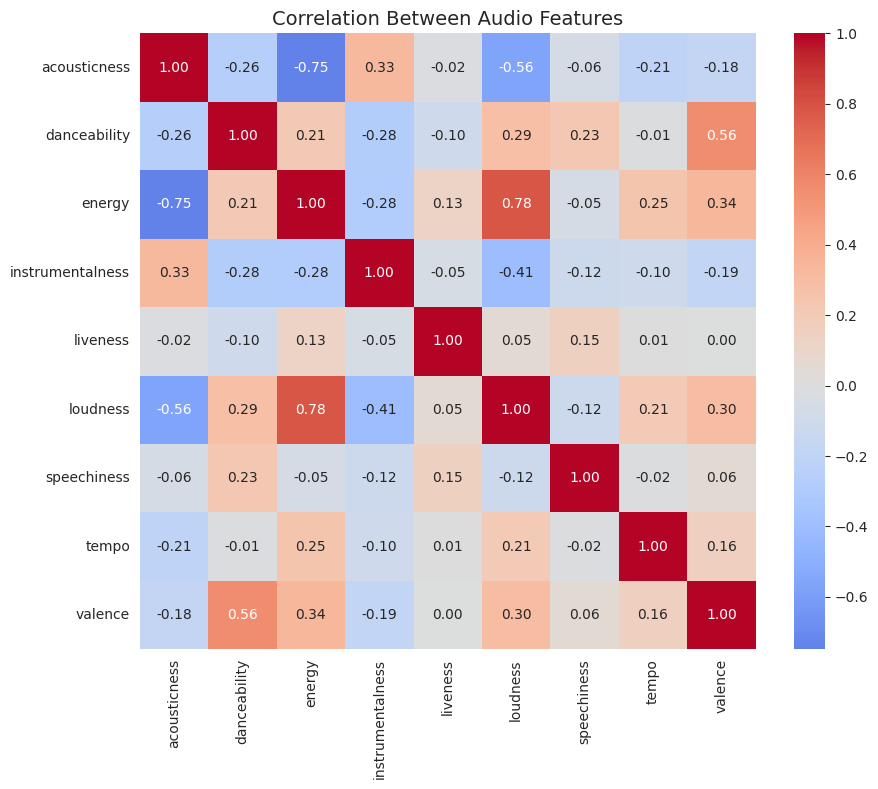

In [11]:
# Correlation heatmap
corr = df[audio_features].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0, fmt='.2f', square=True)
plt.title("Correlation Between Audio Features", fontsize=14)
plt.show()

## 6. Prepare Data for Modelling
K-Means is sensitive to feature scale — `tempo` ranges 0–250 while `danceability` ranges 0–1. We standardise so every feature contributes equally.

In [13]:
# Extract feature matrix
X = df[audio_features].values
print(f"Feature matrix shape: {X.shape}")

# Standardise (mean=0, std=1 for each feature)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"After scaling — mean: {X_scaled.mean():.4f}, std: {X_scaled.std():.4f}")

Feature matrix shape: (156467, 9)
After scaling — mean: 0.0000, std: 1.0000


## 7. Choose Number of Clusters — Elbow Method
We try different values of `k` (number of clusters) and look for the "elbow" in the inertia curve. That's the sweet spot.

**📸 This plot is a classic ML screenshot.**

In [14]:
# Sample 20k rows for the elbow method (full 160k is slow and the curve looks the same)
sample_idx = np.random.RandomState(42).choice(len(X_scaled), size=20000, replace=False)
X_sample = X_scaled[sample_idx]

inertias = []
k_range = range(2, 16)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_sample)
    inertias.append(km.inertia_)
    print(f"k={k}: inertia={km.inertia_:.0f}")

k=2: inertia=136295
k=3: inertia=121619
k=4: inertia=106390
k=5: inertia=95841
k=6: inertia=87537
k=7: inertia=81119
k=8: inertia=76502
k=9: inertia=72466
k=10: inertia=69591
k=11: inertia=67289
k=12: inertia=65557
k=13: inertia=63704
k=14: inertia=62093
k=15: inertia=60598


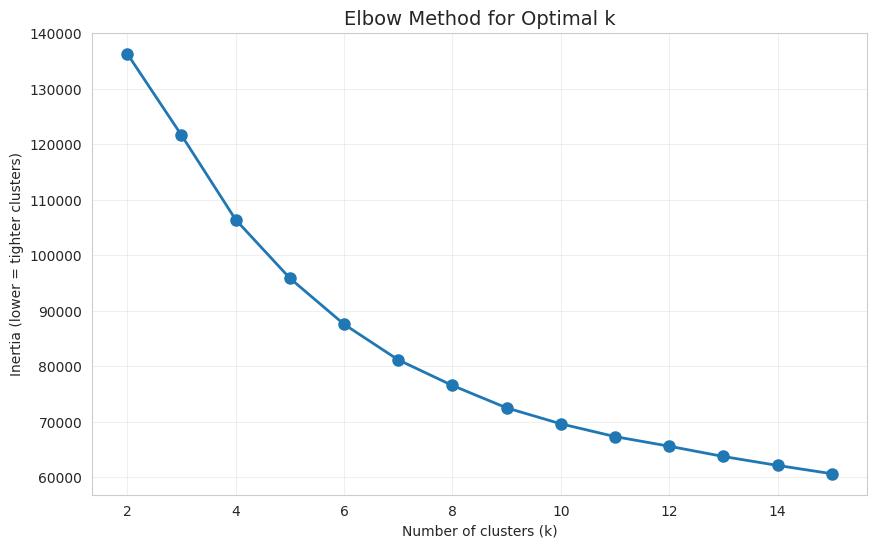

In [15]:
# Plot the elbow
plt.figure(figsize=(10, 6))
plt.plot(k_range, inertias, marker='o', linewidth=2, markersize=8)
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia (lower = tighter clusters)")
plt.title("Elbow Method for Optimal k", fontsize=14)
plt.grid(True, alpha=0.3)
plt.show()

## 8. Train Final K-Means Model
Based on the elbow plot, we pick `k=10`. You can adjust this if your elbow looks different.

In [16]:
# Train on the full dataset
k = 10
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
kmeans.fit(X_scaled)

# Assign each song to a cluster
df['cluster'] = kmeans.labels_

print(f"Trained K-Means with k={k}")
print(f"\nSongs per cluster:")
print(df['cluster'].value_counts().sort_index())

Trained K-Means with k=10

Songs per cluster:
cluster
0    29483
1    18307
2    12016
3    11063
4    15815
5    22799
6     9201
7     4423
8    21170
9    12190
Name: count, dtype: int64


## 9. Evaluate the Model

### 9.1 Silhouette Score
Measures how well-separated the clusters are. Range: -1 to 1. Higher is better.

In [17]:
# Silhouette on a sample (full dataset is too slow)
sil_sample = np.random.RandomState(42).choice(len(X_scaled), size=10000, replace=False)
sil_score = silhouette_score(X_scaled[sil_sample], kmeans.labels_[sil_sample])

print(f"Silhouette Score: {sil_score:.4f}")
print("(Above 0.2 is decent for high-dimensional real-world data like this)")

Silhouette Score: 0.1760
(Above 0.2 is decent for high-dimensional real-world data like this)


### 9.2 Visualise Clusters in 2D with PCA
Reduce the 9 audio features to 2 dimensions so we can plot them.

**📸 This is your money screenshot — colourful clusters!**

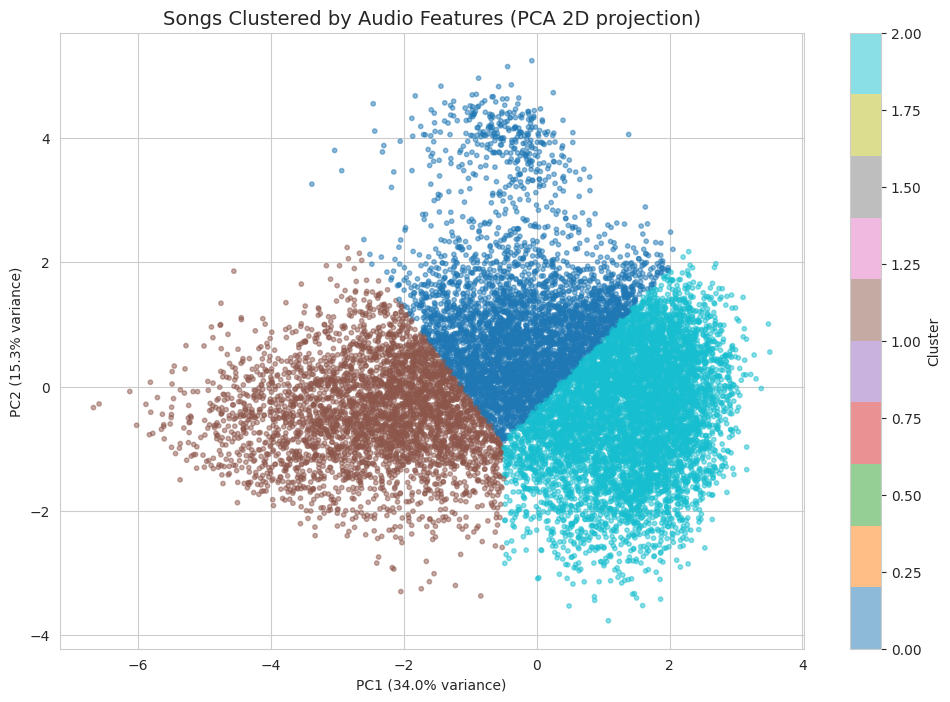

In [37]:
# Reduce to 2D using PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)


plt.figure(figsize=(12, 8))
scatter = plt.scatter(
    X_pca[plot_sample, 0],
    X_pca[plot_sample, 1],
    c=kmeans.labels_[plot_sample],
    cmap='tab10',
    alpha=0.5,
    s=10
)
plt.colorbar(scatter, label="Cluster")
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)")
plt.title("Songs Clustered by Audio Features (PCA 2D projection)", fontsize=14)
plt.show()

In [28]:
# Average audio features per cluster
cluster_profiles = df.groupby('cluster')[audio_features].mean().round(2)
cluster_profiles

,acousticness,danceability,energy,instrumentalness,liveness,loudness,speechiness,tempo,valence
cluster,,,,,,,,,
0,0.19,0.72,0.69,0.03,0.15,-7.96,0.09,114.74,0.77
1,0.85,0.40,0.20,0.04,0.18,-15.44,0.05,93.50,0.27
2,0.70,0.45,0.34,0.04,0.16,-12.56,0.06,157.57,0.47
3,0.79,0.56,0.38,0.80,0.18,-13.64,0.07,117.88,0.67
4,0.11,0.46,0.79,0.07,0.19,-6.65,0.09,160.10,0.58
5,0.76,0.63,0.37,0.03,0.17,-11.86,0.07,107.95,0.69
6,0.41,0.50,0.62,0.10,0.73,-9.85,0.10,118.89,0.54
7,0.50,0.67,0.26,0.01,0.32,-18.33,0.88,107.47,0.55
8,0.14,0.53,0.68,0.07,0.17,-7.49,0.07,106.78,0.37


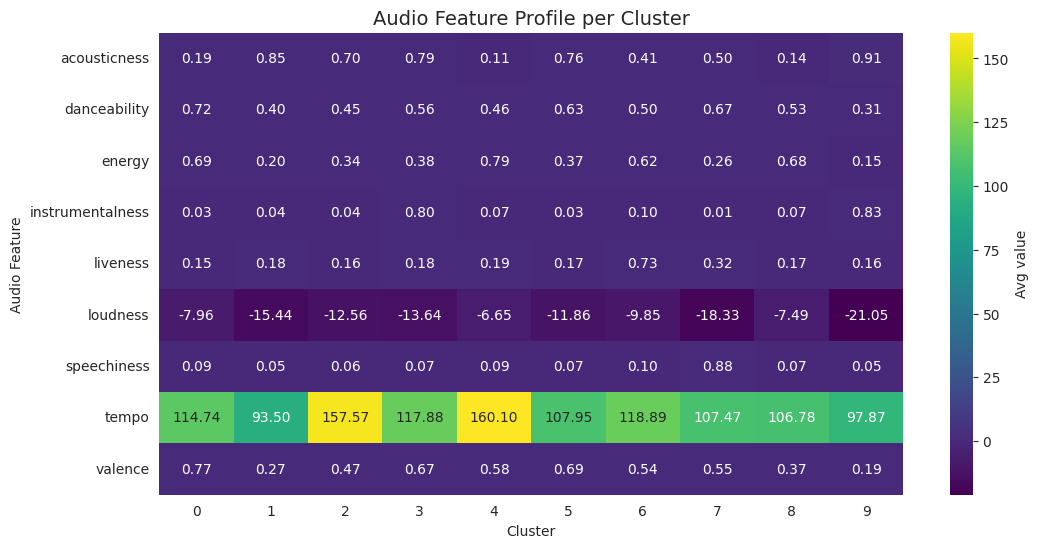

In [31]:
# Heatmap of cluster profiles — easier to see which clusters are which
plt.figure(figsize=(12, 6))
sns.heatmap(cluster_profiles.T, annot=True, cmap='viridis', fmt='.2f', cbar_kws={'label': 'Avg value'})
plt.title("Audio Feature Profile per Cluster", fontsize=14)
plt.xlabel("Cluster")
plt.ylabel("Audio Feature")
plt.show()

## 10. Build the Recommendation Function

The logic:
1. User gives us a song name
2. Find that song in the dataset
3. Find its cluster
4. Compute cosine similarity to all other songs in the same cluster
5. Return the top 10 most similar songs

In [21]:
def recommend_songs(song_name, df, X_scaled, n_recommendations=10):
    """
    Recommend songs similar to the given song.

    Parameters:
        song_name (str): name of the song to find recommendations for
        df (DataFrame): the songs dataframe with 'cluster' column
        X_scaled (ndarray): the scaled feature matrix
        n_recommendations (int): how many songs to return

    Returns:
        DataFrame of recommended songs
    """
    # Find the song (case-insensitive, partial match)
    matches = df[df['name'].str.lower().str.contains(song_name.lower(), na=False)]

    if len(matches) == 0:
        print(f"No song found matching '{song_name}'")
        return None

    # Take the most popular match if multiple
    song = matches.sort_values('popularity', ascending=False).iloc[0]
    song_idx = song.name  # this is the dataframe index

    print(f"🎵 Finding songs similar to: '{song['name']}' by {song['artists']}")
    print(f"   (Cluster: {song['cluster']}, Popularity: {song['popularity']})\n")

    # Get songs in the same cluster
    cluster_id = song['cluster']
    cluster_mask = df['cluster'] == cluster_id
    cluster_indices = df[cluster_mask].index

    # Compute cosine similarity between this song and all others in the cluster
    song_vector = X_scaled[song_idx].reshape(1, -1)
    cluster_vectors = X_scaled[cluster_indices]
    similarities = cosine_similarity(song_vector, cluster_vectors)[0]

    # Get top N (excluding the song itself)
    top_indices_in_cluster = np.argsort(similarities)[::-1][1:n_recommendations+1]
    top_df_indices = cluster_indices[top_indices_in_cluster]

    recommendations = df.loc[top_df_indices, ['name', 'artists', 'year', 'popularity']].copy()
    recommendations['similarity'] = similarities[top_indices_in_cluster].round(3)

    return recommendations.reset_index(drop=True)

### 10.1 Test the Recommender

In [22]:
# Try a few example songs
recommend_songs("Bohemian Rhapsody", df, X_scaled)

🎵 Finding songs similar to: 'Bohemian Rhapsody - 2011 Mix' by ['Queen']
   (Cluster: 2, Popularity: 75)



,name,artists,year,popularity,similarity
0,Bohemian Rhapsody,['Queen'],2006,60,0.985
1,你要的愛,['Penny Tai'],2001,54,0.984
2,Perfume a Tus Pies,['En Espíritu Y En Verdad'],2007,62,0.970
3,Tiny Dancer,['Elton John'],1990,36,0.969
4,Where Did You Sleep Last Night,"['C-BONY', 'Guy C-bony', 'guy sibony']",1937,0,0.969
5,Miraiyosouzu II,['DREAMS COME TRUE'],1989,36,0.968
6,Good Good Father - Live,['Casting Crowns'],2015,55,0.966
7,Cuerpo Sin Alma,['Riccardo Cocciante'],1974,47,0.962
8,The King Must Die,['Elton John'],1970,31,0.960
9,Black Metallic,['Catherine Wheel'],1992,40,0.960


In [23]:
recommend_songs("Hotel California", df, X_scaled)

🎵 Finding songs similar to: 'Hotel California - 2013 Remaster' by ['Eagles']
   (Cluster: 4, Popularity: 82)



,name,artists,year,popularity,similarity
0,Crystal Flame,['Blues Traveler'],1990,31,0.986
1,My Hometown,['Charlie Robison'],1998,59,0.983
2,Party Girl,['Elvis Costello & The Attractions'],1979,29,0.983
3,"Amor, Amor",['Industria del Amor'],1993,39,0.977
4,Dejenme Si Estoy Llorando,['Los Angeles De Charly'],2003,47,0.972
5,That's Alright - 2016 Remaster,['Fleetwood Mac'],1982,37,0.970
6,Someone Like You,['Daryl Hall'],1986,29,0.968
7,Take Good Care of Me,['Jonathan Butler'],1986,25,0.967
8,Go To Her - Version One,['Jefferson Airplane'],1966,20,0.966
9,Jaws Theme Swimming,['Brand New'],2003,44,0.965


In [24]:
recommend_songs("Smells Like Teen Spirit", df, X_scaled)

🎵 Finding songs similar to: 'Smells Like Teen Spirit - 2015 Remaster' by ['Tori Amos']
   (Cluster: 2, Popularity: 54)



,name,artists,year,popularity,similarity
0,Verborgenheit,"['Hugo Wolf', 'Jussi Björling']",1953,0,0.998
1,Kaulana Kawaihae,"[""Israel Kamakawiwo'ole""]",1993,38,0.997
2,"Turandot:""Non piangere liu""","['Giacomo Puccini', 'Richard Tucker', 'Fausto ...",1949,0,0.995
3,Mr. Lonely,['Floyd Cramer'],1965,19,0.995
4,Finale,"['Alfred Drake', 'Joan Roberts', 'Oklahoma Cho...",1943,4,0.995
5,Todo Pasara,['Matt Monro'],1969,23,0.994
6,Passover Seder Festival: A Passover Service: T...,"['Sholom Secunda', 'Richard Tucker']",1950,0,0.994
7,I Speak To The Stars (with Leith Stevens & His...,"['Doris Day', 'Leith Stevens And His Orchestra']",1952,1,0.994
8,Plantasia,['Mort Garson'],1976,52,0.994
9,Miles Apart,['Nick Wilson'],2017,60,0.994


## 11. Save the Model
We save everything the Streamlit app will need: the K-Means model, the scaler, and a slim version of the dataframe.

In [25]:
# Save the trained K-Means model
with open('kmeans_model.pkl', 'wb') as f:
    pickle.dump(kmeans, f)

# Save the scaler
with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

# Save a slim dataframe (just what the app needs)
df_slim = df[['name', 'artists', 'year', 'popularity', 'cluster'] + audio_features].copy()
df_slim.to_csv('songs_with_clusters.csv', index=False)

# Save the scaled features (for similarity computation)
np.save('X_scaled.npy', X_scaled)

print("✅ Saved files:")
print("  - kmeans_model.pkl")
print("  - scaler.pkl")
print("  - songs_with_clusters.csv")
print("  - X_scaled.npy")

✅ Saved files:
  - kmeans_model.pkl
  - scaler.pkl
  - songs_with_clusters.csv
  - X_scaled.npy


In [26]:
# Download files from Colab to your computer
from google.colab import files

files.download('kmeans_model.pkl')
files.download('scaler.pkl')
files.download('songs_with_clusters.csv')
files.download('X_scaled.npy')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [38]:
# Shrink the CSV — drop audio feature columns (we already have them in X_scaled.npy)
df_app = df[['name', 'artists', 'year', 'popularity', 'cluster']].copy()
df_app.to_csv('songs_for_app.csv', index=False)

# Also save X_scaled in compressed format
np.savez_compressed('X_scaled.npz', X=X_scaled)

# Download the slimmer versions
from google.colab import files
files.download('songs_for_app.csv')
files.download('X_scaled.npz')

import os
print(f"songs_for_app.csv: {os.path.getsize('songs_for_app.csv') / 1024 / 1024:.1f} MB")
print(f"X_scaled.npz: {os.path.getsize('X_scaled.npz') / 1024 / 1024:.1f} MB")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

songs_for_app.csv: 9.0 MB
X_scaled.npz: 4.9 MB


## 12. Summary

✅ **Loaded** 160k Spotify songs from Kaggle  
✅ **Cleaned** duplicates and non-music entries  
✅ **Explored** the data with distribution, correlation, and trend plots  
✅ **Trained** a K-Means model with 10 clusters  
✅ **Evaluated** with silhouette score and 2D PCA visualisation  
✅ **Built** a recommendation function using cosine similarity  
✅ **Saved** the model for the Streamlit web app  

### Next steps
1. Take screenshots of the most interesting outputs (see 📸 markers)
2. Move on to the Streamlit app to make this interactive
3. Deploy to Streamlit Community Cloud
